In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path
import xcdat as xc
import cmasher as cmr
import xarray as xr
import sys

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *
# from taylor_setup import *
from setup_diagnostic import *

In [2]:
# %% 1. Settings: regress existing window covariance maps ON each member's SEP index
import numpy as np
from pathlib import Path
from datetime import datetime, timezone

covreg_core_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412")
covreg_stationarity_dir = covreg_core_dir / "stationarity"
covreg_regional_path = covreg_stationarity_dir / "regional/march_n178_regional.npy"
covreg_experiments = ["historical", "historical_matched", "amip_hist"]
covreg_region, covreg_index_key = "SEP", "cov_Zi_R"
covreg_quantities = ["cov_Zi_R", "cov_Zi_Ri"]
covreg_quantity_units = {"cov_Zi_R": "W m-2", "cov_Zi_Ri": "W m-2"}
covreg_min_windows = 3

# All regressions are across START YEARS, not the monthly anomalies themselves.
# Keep the existing monthly preprocessing; apply NO additional window detrend.
# Each member supplies its own predictor. We do not regress against the MMM line.
covreg_save, covreg_overwrite = True, False
covreg_savepath = covreg_stationarity_dir / "SEP_relationships/all_experiments_SEP_covariance_regressions.npy"
covreg_calculated, covreg_aggregated = False, False




In [3]:
# %% 2. Small helpers: spatial average, finite mean, and a window-wise linear fit
def covreg_area_mean(fields, weights):
    """Weighted average over the final two axes, plus the fraction of area used."""
    support = np.isfinite(weights) & (weights > 0)
    if not support.any():
        raise ValueError("No positive finite area weights.")
    w = weights[support] / weights[support].max()
    values = np.ma.asarray(fields[..., support], dtype=float).filled(np.nan)
    finite = np.isfinite(values)
    total, denominator = np.sum(np.where(finite, values, 0.) * w, axis=-1), np.sum(finite * w, axis=-1)
    mean = np.divide(total, denominator, out=np.full_like(total, np.nan), where=denominator > 0)
    return mean, denominator / w.sum()


def covreg_mean_and_count(values):
    """Arithmetic mean over axis 0; missing contributors do not become zeros."""
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    total, count = np.where(finite, values, 0.).sum(axis=0), finite.sum(axis=0)
    mean = np.divide(total, count, out=np.full_like(total, np.nan), where=count > 0)
    return mean, count


def covreg_fit(index, field, min_windows=3):
    """Fit field(s,i) = intercept(i) + slope(i)*index(s) + residual(s,i).

    index: (start_year,), field: (start_year, lat, lon).
    Every grid cell uses its own paired finite windows, with an intercept.
    No p-values: n_windows counts pairs, NOT independent temporal samples.
    """
    index = np.asarray(index, dtype=float)
    field = np.ma.asarray(field, dtype=float).filled(np.nan)
    if index.ndim != 1 or field.ndim != 3 or field.shape[0] != len(index):
        raise ValueError("Expected index (window,) and field (window, lat, lon).")
    if min_windows < 3:
        raise ValueError("Use at least three paired windows.")

    # Center on the paired means at each cell. All spatial fits are evaluated
    # together; the only reduction is over the window axis, not lat/lon.
    x = index[:, None, None]
    valid = np.isfinite(x) & np.isfinite(field)
    count = valid.sum(axis=0)
    mx = np.divide(np.where(valid, x, 0.).sum(axis=0), count, out=np.zeros(field.shape[1:]), where=count > 0)
    my = np.divide(np.where(valid, field, 0.).sum(axis=0), count, out=np.zeros(field.shape[1:]), where=count > 0)
    dx, dy = np.where(valid, x, mx) - mx, np.where(valid, field, my) - my
    xx, yy, xy = np.sum(dx*dx, axis=0), np.sum(dy*dy, axis=0), np.sum(dx*dy, axis=0)

    # Range checks prevent round-off from inventing variance in constant arrays.
    varying_x = np.max(np.where(valid, x, -np.inf), axis=0) > np.min(np.where(valid, x, np.inf), axis=0)
    varying_y = np.max(np.where(valid, field, -np.inf), axis=0) > np.min(np.where(valid, field, np.inf), axis=0)
    fit_ok = (count >= min_windows) & varying_x & (xx > 0)
    xy = np.where(varying_y, xy, 0.)
    slope = np.divide(xy, xx, out=np.full_like(xx, np.nan), where=fit_ok)
    denominator = np.sqrt(xx) * np.sqrt(yy)
    corr = np.divide(xy, denominator, out=np.full_like(xx, np.nan),
                     where=fit_ok & varying_y & (denominator > 0))
    corr = np.clip(corr, -1., 1.)
    intercept = np.where(fit_ok, my - slope*mx, np.nan)

    # One SD means the SD of THIS member's index over all its finite windows,
    # using ddof=1. It is not a different predictor normalization at each cell.
    finite_index = index[np.isfinite(index)]
    index_sd = float(np.std(finite_index, ddof=1)) if len(finite_index) >= 2 else np.nan
    if len(finite_index) and np.ptp(finite_index) == 0:
        index_sd = 0.
    values = {"slope": slope, "corr": corr, "intercept": intercept, "slope_per_index_sd": slope*index_sd}
    return values, count




In [4]:
# %% 3. Load the small regional bundle; establish coordinates and output names
# This file supplies the SAME masks, weights, member order and window dates as
# the regional time-series plots. Trusted pickle files only.
covreg_regional = np.load(covreg_regional_path, allow_pickle=True).item()
covreg_meta = covreg_regional["metadata"]
covreg_years = np.asarray(covreg_meta["start_years"])
covreg_start_months = np.asarray(covreg_meta["start_months"], dtype="datetime64[M]")
covreg_end_months = np.asarray(covreg_meta["end_months"], dtype="datetime64[M]")
covreg_lat, covreg_lon = [np.asarray(covreg_meta[k], dtype=float) for k in ["lat", "lon"]]
covreg_shape = (len(covreg_lat), len(covreg_lon))
if (covreg_years.ndim != 1 or len(covreg_years) < covreg_min_windows
        or int(covreg_meta["window_months"]) != 178 or np.any(np.diff(covreg_years) != 1)
        or covreg_start_months.shape != covreg_years.shape or covreg_end_months.shape != covreg_years.shape
        or np.any(covreg_start_months.astype(int) % 12 != 2)
        or not np.array_equal(covreg_start_months.astype("datetime64[Y]").astype(int) + 1970, covreg_years)
        or not np.array_equal(covreg_end_months, covreg_start_months + np.timedelta64(177, "M"))):
    raise ValueError("Expected consecutive March-start years and matching 178-month dates.")
if any(v.ndim != 1 or not np.isfinite(v).all() for v in [covreg_lat, covreg_lon]):
    raise ValueError("Expected finite 1-D lat/lon coordinates.")
covreg_weights = np.ma.asarray(covreg_meta["weights"], dtype=float).filled(np.nan)
mask = np.ma.asarray(covreg_regional["regions"][covreg_region], dtype=float).filled(np.nan)
covreg_mask = np.isfinite(mask) & (mask != 0)
if covreg_weights.shape != covreg_shape or covreg_mask.shape != covreg_shape:
    raise ValueError("Region and weights must match the saved map grid.")
if np.any(np.isfinite(covreg_weights) & (covreg_weights < 0)):
    raise ValueError("Negative area weights are not valid.")
covreg_region_weights = np.where(covreg_mask & np.isfinite(covreg_weights) & (covreg_weights > 0), covreg_weights, 0.)
if covreg_region_weights.sum() <= 0:
    raise ValueError("The requested region has no positive-weight cells.")
covreg_region_weights /= covreg_region_weights.sum()

# Experiments stay separate even though historical_matched is a subset of the
# coupled collection. No pairing of AMIP and historical ensemble members occurs.
allowed = {"historical", "historical_matched", "amip_hist"}
if not covreg_experiments or len(set(covreg_experiments)) != len(covreg_experiments) or not set(covreg_experiments) <= allowed:
    raise ValueError("Choose a nonduplicated subset of the three experiment names.")
if not covreg_quantities or len(set(covreg_quantities)) != len(covreg_quantities):
    raise ValueError("Choose nonduplicated response-map quantities.")
covreg_models = {e: list(covreg_meta["model_names"][e]) for e in covreg_experiments}
for experiment, names in covreg_models.items():
    if not names or len(set(names)) != len(names):
        raise ValueError(f"{experiment}: expected nonempty unique model names.")
if allowed <= set(covreg_experiments):
    shared = set(covreg_models["historical"]) & set(covreg_models["amip_hist"])
    if set(covreg_models["historical_matched"]) != shared:
        raise ValueError("historical_matched must be the AMIP/historical model intersection.")

# Add another saved map to covreg_quantities and declare its units above; the
# calculation/storage/aggregation loops then include it without other edits.
covreg_statistics = ["slope", "corr", "intercept", "slope_per_index_sd"]
covreg_index_units = covreg_quantity_units[covreg_index_key]
covreg_metric_info = {}
for quantity in covreg_quantities:
    unit = covreg_quantity_units[quantity]
    units = {"slope": "1" if unit == covreg_index_units else f"({unit}) / ({covreg_index_units})",
             "corr": "1", "intercept": unit, "slope_per_index_sd": unit}
    for statistic in covreg_statistics:
        key = f"{statistic}_{quantity}"
        covreg_metric_info[key] = {"quantity": quantity, "statistic": statistic, "units": units[statistic],
                                   "meaning": f"{statistic} of window {quantity} ON own-member {covreg_region} {covreg_index_key}"}




In [5]:
# %% 4. Fit each member, retaining maps and counts; load only one model at a time
covreg_calculated, covreg_aggregated = False, False
covreg_member_values = {e: {key: {} for key in covreg_metric_info} for e in covreg_experiments}
covreg_n_windows = {e: {q: {} for q in covreg_quantities} for e in covreg_experiments}
covreg_member_index, covreg_index_coverage, covreg_member_labels = [{e: {} for e in covreg_experiments} for _ in range(3)]
covreg_self_check, covreg_sources = [{e: {} for e in covreg_experiments} for _ in range(2)]
for experiment in covreg_experiments:
    for model in covreg_models[experiment]:
        print(f"{experiment} / {model}", flush=True)
        path = covreg_stationarity_dir / f"march_n178_{experiment}_{model}_member_values.npy"
        source = np.load(path, allow_pickle=True).item()
        index = np.asarray(covreg_regional["member_values"][experiment][covreg_index_key][covreg_region][model], dtype=float)
        if index.ndim != 2 or index.shape[0] < 1 or index.shape[1] != len(covreg_years):
            raise ValueError(f"{experiment}/{model}: index must be (member, start_year).")
        n_members = len(index)
        for quantity in set(covreg_quantities + [covreg_index_key]):
            if np.shape(source[quantity]) != (n_members, len(covreg_years)) + covreg_shape:
                raise ValueError(f"{experiment}/{model}/{quantity}: expected (member, start_year, lat, lon).")

        # Recompute only the small regional index to catch stale files/order.
        # The large source dictionaries contain no independent time/grid labels.
        # Their correspondence to the archived labels remains an input assumption.
        reconstructed, coverage = covreg_area_mean(source[covreg_index_key], covreg_region_weights)
        if not np.allclose(index, reconstructed, rtol=1e-10, atol=1e-12, equal_nan=True):
            raise ValueError(f"{experiment}/{model}: saved regional index differs from these source maps.")
        labels = np.asarray(covreg_meta["member_labels"][experiment][model])
        if labels.ndim != 1 or len(labels) != n_members or len(set(labels.tolist())) != n_members:
            raise ValueError(f"{experiment}/{model}: invalid member labels.")
        covreg_member_labels[experiment][model] = labels.copy()
        covreg_member_index[experiment][model], covreg_index_coverage[experiment][model] = index.copy(), coverage
        info = path.stat()
        covreg_sources[experiment][model] = {"path": str(path), "size_bytes": info.st_size, "mtime_ns": info.st_mtime_ns}
        collected = {key: [] for key in covreg_metric_info}
        counts = {q: [] for q in covreg_quantities}
        check = {"eligible": np.zeros(n_members, dtype=bool), "regional_mean_slope": np.full(n_members, np.nan)}

        # All spatial cells are fitted simultaneously, reducing over start year.
        # To try a new calculation, register its output before this loop, calculate
        # it here, then append it to collected with the other member maps below.
        for member in range(n_members):
            x = index[member]
            for quantity in covreg_quantities:
                y = np.ma.asarray(source[quantity][member], dtype=float).filled(np.nan)
                fitted, n = covreg_fit(x, y, covreg_min_windows)
                for statistic, values in fitted.items():
                    collected[f"{statistic}_{quantity}"].append(values)
                counts[quantity].append(n)

                # For the SAME field used to make the index, area-mean slope=1.
                # This requires complete regional coverage across finite-index
                # windows. Missing cells with changing weights can break it, so
                # those members are recorded as ineligible, not silently tested.
                if quantity == covreg_index_key:
                    use = np.isfinite(x)
                    complete = np.isfinite(y[use][:, covreg_region_weights > 0]).all()
                    eligible = use.sum() >= covreg_min_windows and np.ptp(x[use]) > 0 and complete
                    if eligible:
                        average, _ = covreg_area_mean(fitted["slope"], covreg_region_weights)
                        check["eligible"][member], check["regional_mean_slope"][member] = True, average
                        if not np.isclose(average, 1., rtol=1e-8, atol=1e-10):
                            raise ValueError(f"{experiment}/{model}/{member}: regional slope identity failed ({average}).")
        for key, values in collected.items():
            covreg_member_values[experiment][key][model] = np.stack(values)
        for quantity, values in counts.items():
            covreg_n_windows[experiment][quantity][model] = np.stack(values)
        covreg_self_check[experiment][model] = check
        del source, y, fitted, collected
covreg_calculated = True




historical / ACCESS-CM2
historical / ACCESS-ESM1-5
historical / AWI-CM-1-1-MR
historical / AWI-ESM-1-1-LR
historical / BCC-CSM2-MR
historical / BCC-ESM1
historical / CAMS-CSM1-0
historical / CAS-ESM2-0
historical / CESM2-FV2
historical / CESM2-WACCM-FV2
historical / CESM2-WACCM
historical / CESM2
historical / CIESM
historical / CMCC-CM2-HR4
historical / CMCC-CM2-SR5
historical / CMCC-ESM2
historical / CNRM-CM6-1-HR
historical / CNRM-CM6-1
historical / CNRM-ESM2-1
historical / CanESM5-CanOE
historical / CanESM5
historical / E3SM-1-0
historical / E3SM-1-1-ECA
historical / E3SM-1-1
historical / EC-Earth3-AerChem
historical / EC-Earth3-Veg-LR
historical / EC-Earth3-Veg
historical / EC-Earth3
historical / FGOALS-f3-L
historical / FGOALS-g3
historical / FIO-ESM-2-0
historical / GISS-E2-1-G-CC
historical / GISS-E2-1-G
historical / GISS-E2-1-H
historical / IITM-ESM
historical / INM-CM4-8
historical / INM-CM5-0
historical / IPSL-CM5A2-INCA
historical / IPSL-CM6A-LR-INCA
historical / IPSL-CM6A-L

In [6]:
# %% 5. Mean member diagnostics within model, then take an equal-model MMM
if not covreg_calculated:
    raise RuntimeError("Complete the member calculations first.")
covreg_model_means, covreg_MMM, covreg_model_n_valid, covreg_MMM_n_valid = [{e: {} for e in covreg_experiments} for _ in range(4)]
for experiment in covreg_experiments:
    for key in covreg_metric_info:
        means, counts = zip(*(covreg_mean_and_count(covreg_member_values[experiment][key][model]) for model in covreg_models[experiment]))
        covreg_model_means[experiment][key], covreg_model_n_valid[experiment][key] = np.stack(means), np.stack(counts)
        covreg_MMM[experiment][key], covreg_MMM_n_valid[experiment][key] = covreg_mean_and_count(np.stack(means))

# These are means of slopes/correlations, NOT fits of mean maps. Correlations are
# arithmetic means, matching the existing workflow; no Fisher-z transformation.
# The per-index-SD slopes are scaled member by member BEFORE either averaging.
covreg_archive = {
    "schema": "sep_covariance_regressions", "schema_version": 1,
    "member_values": covreg_member_values, "model_means": covreg_model_means, "MMM": covreg_MMM,
    "model_n_valid": covreg_model_n_valid, "MMM_n_valid": covreg_MMM_n_valid, "n_windows": covreg_n_windows,
    "member_index": covreg_member_index, "index_valid_area_fraction": covreg_index_coverage,
    "self_regression_check": covreg_self_check, "model_names": covreg_models, "member_labels": covreg_member_labels,
    "metric_info": covreg_metric_info, "response_quantities": list(covreg_quantities),
    "coordinates": {"lat": covreg_lat, "lon": covreg_lon, "start_year": covreg_years,
                    "start_month": covreg_start_months, "end_month": covreg_end_months},
    "metadata": {"created_utc": datetime.now(timezone.utc).isoformat(), "experiments": list(covreg_experiments),
                 "index_region": covreg_region, "index_quantity": covreg_index_key, "index_units": covreg_index_units,
                 "region_mask": covreg_mask, "region_weights": covreg_region_weights,
                 "region_info": covreg_regional.get("region_info", {}).get(covreg_region, {}),
                 "regional_path": str(covreg_regional_path), "source_files": covreg_sources,
                 "member_label_kind": covreg_meta.get("member_label_kind", "unspecified archive labels"),
                 "window_months": 178, "min_windows": covreg_min_windows,
                 "fit": "Response map on own-member regional index; intercept included; paired finite windows; equal window weights",
                 "preprocessing": "Use saved monthly-deseasonalized/detrended covariances; no extra across-window detrending",
                 "aggregation": "Arithmetic member diagnostics within model, then equal-model means; no Fisher-z",
                 "sd_scaling": "Multiply each member slope by its index SD over all finite windows, ddof=1, before aggregation",
                 "cautions": "Descriptive co-variation, not causal feedback; overlapping windows are not independent; regional self-slope=1 by construction with complete fixed coverage"},
}
covreg_aggregated = True
print("Ready: member maps, model means and equal-model MMMs for", covreg_experiments)
# Example: covreg_member_values["amip_hist"]["slope_cov_Zi_Ri"]["TaiESM1"][0]
# Example: covreg_MMM["historical_matched"]["corr_cov_Zi_R"]
# The model axis of covreg_model_means follows covreg_models[experiment].




Ready: member maps, model means and equal-model MMMs for ['historical', 'historical_matched', 'amip_hist']


In [7]:
# %% 6. Save the reduced bundle separately; original archives are never replaced
import os
import tempfile

if covreg_save:
    if not (covreg_calculated and covreg_aggregated):
        raise RuntimeError("Complete calculation and aggregation before saving.")
    covreg_savepath.parent.mkdir(parents=True, exist_ok=True)
    if covreg_savepath.exists() and not covreg_overwrite:
        raise FileExistsError(f"Already exists: {covreg_savepath}. Change filename or explicitly enable overwrite.")
    fd, temporary = tempfile.mkstemp(prefix=".covreg_", suffix=".tmp", dir=covreg_savepath.parent)
    try:
        with os.fdopen(fd, "wb") as handle:
            np.save(handle, covreg_archive, allow_pickle=True)
            handle.flush()
            os.fsync(handle.fileno())
        if covreg_overwrite:
            os.replace(temporary, covreg_savepath)
        else:
            os.link(temporary, covreg_savepath)
    finally:
        if os.path.exists(temporary):
            os.unlink(temporary)
    print(f"Saved: {covreg_savepath}")




Saved: /scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/SEP_relationships/all_experiments_SEP_covariance_regressions.npy


In [8]:
# %% 7. Load-only option: can run on its own; does not overwrite new calculations
import numpy as np
from pathlib import Path

load_covreg_results = False
if load_covreg_results:
    covreg_loadpath = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/SEP_relationships/all_experiments_SEP_covariance_regressions.npy")
    loaded_covreg_archive = np.load(covreg_loadpath, allow_pickle=True).item()
    if loaded_covreg_archive.get("schema") != "sep_covariance_regressions" or loaded_covreg_archive.get("schema_version") != 1:
        raise ValueError("Unexpected covariance-regression archive format.")




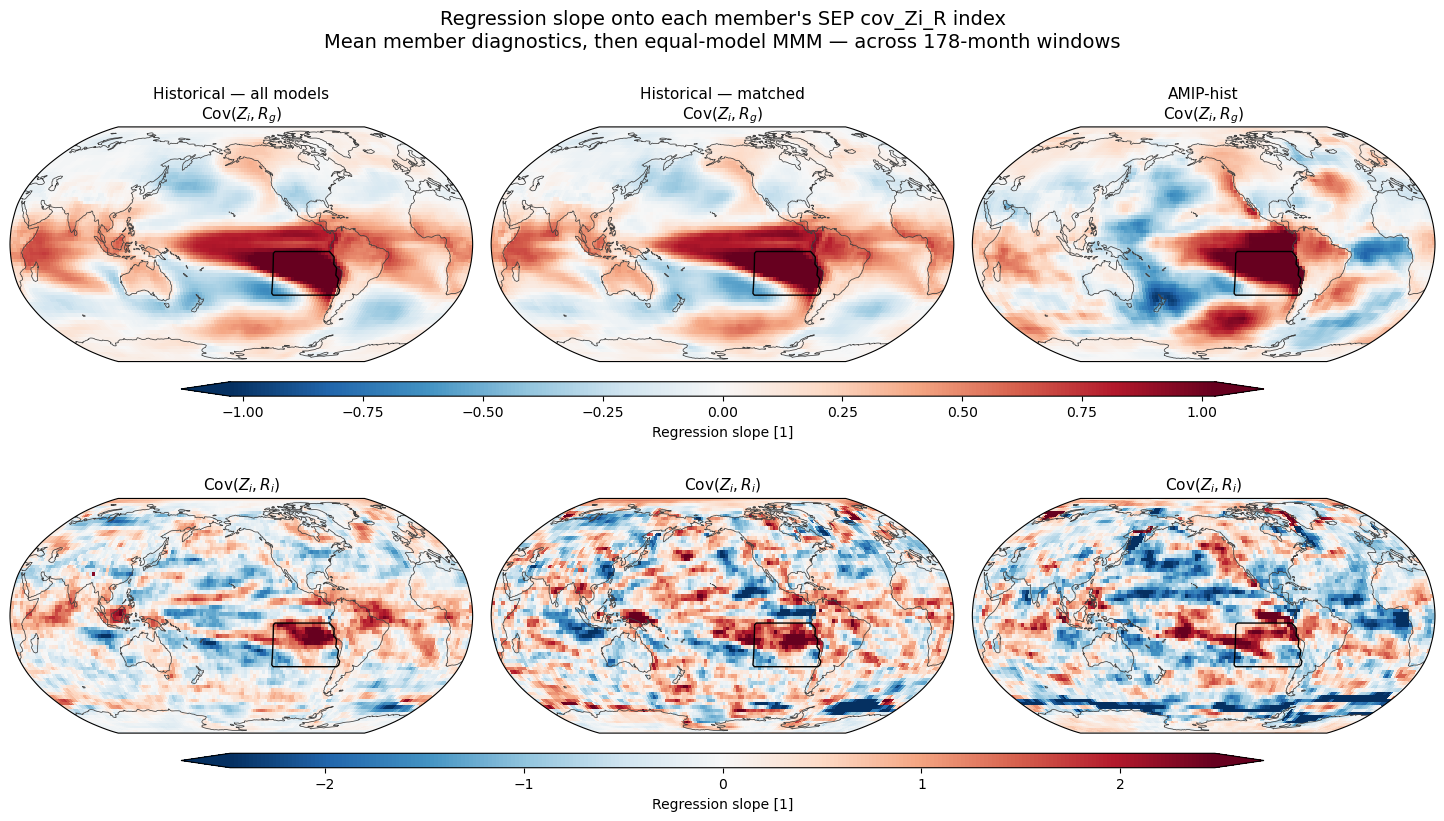

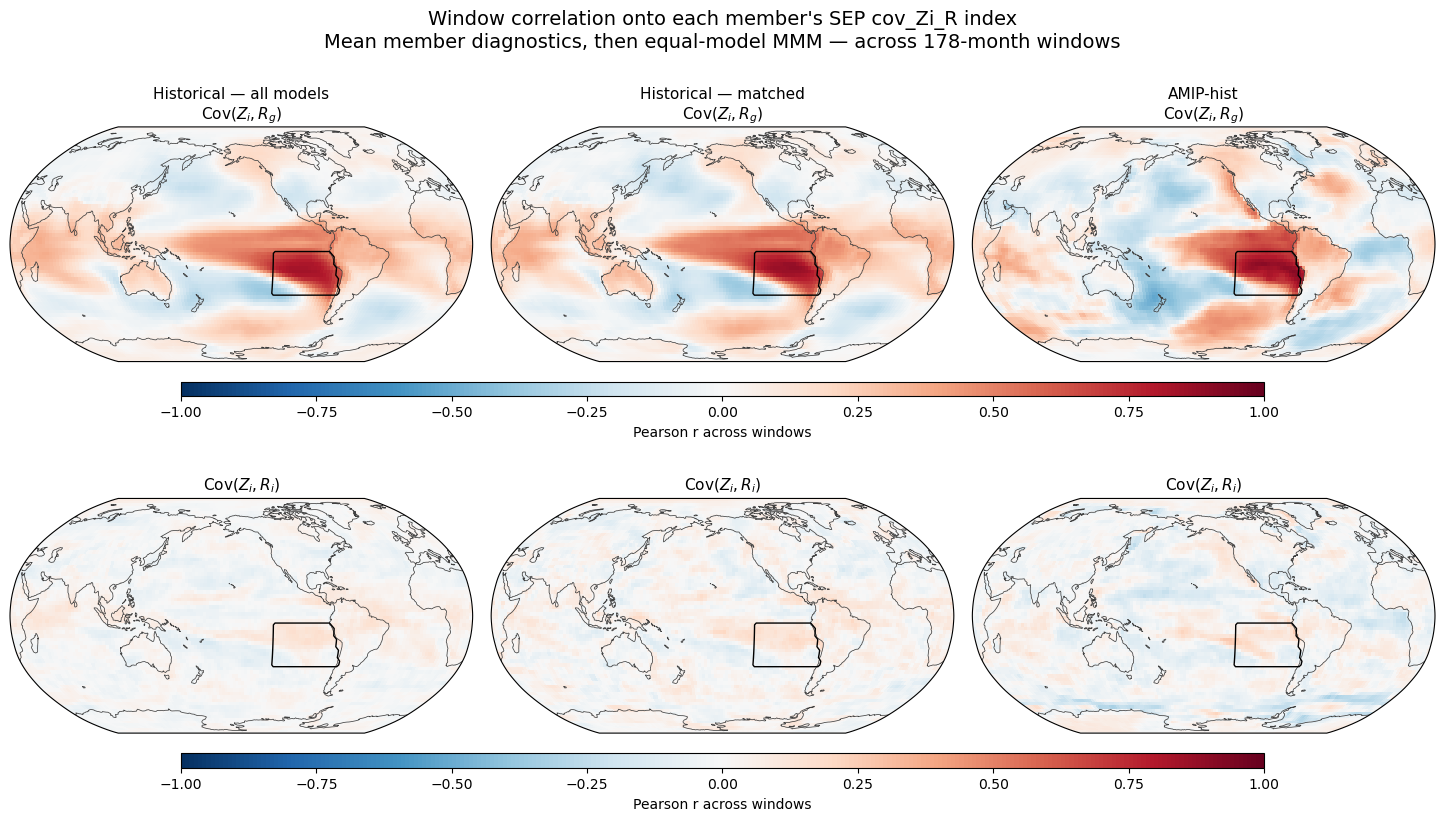

In [9]:
# %% 8. Plot MMM slopes and correlations: rows=fields, columns=experiments
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

covreg_plot_archive = covreg_archive  # For saved results: loaded_covreg_archive
covreg_plot_statistics = ["slope", "corr"]  # Also available: "slope_per_index_sd", "intercept"
covreg_plot_experiments = list(covreg_plot_archive["metadata"]["experiments"])
covreg_plot_quantities = list(covreg_plot_archive["response_quantities"])
covreg_plot_limits = {}  # Optional absolute limits, e.g. {"slope_cov_Zi_R": 2., "slope_cov_Zi_Ri": 20.}
covreg_plot_percentile = 98  # One shared symmetric scale per row across all experiments.
covreg_plot_mask = None  # Optional full-grid Boolean or 1/NaN inclusion mask; DISPLAY ONLY.
covreg_show_region = True
covreg_figure_dir = None  # Or Path("./plots/SEP_covariance_regressions"); defaults to no figure files.

lat, lon = [np.asarray(covreg_plot_archive["coordinates"][k]) for k in ["lat", "lon"]]
mask = np.ma.asarray(True if covreg_plot_mask is None else covreg_plot_mask, dtype=float).filled(np.nan)
plot_support = np.broadcast_to(np.isfinite(mask) & (mask != 0), (len(lat), len(lon)))
region_mask = np.asarray(covreg_plot_archive["metadata"]["region_mask"], dtype=bool)
experiment_labels = {"historical": "Historical — all models", "historical_matched": "Historical — matched", "amip_hist": "AMIP-hist"}
quantity_labels = {"cov_Zi_R": r"$\mathrm{Cov}(Z_i,R_g)$", "cov_Zi_Ri": r"$\mathrm{Cov}(Z_i,R_i)$"}
statistic_labels = {"slope": "Regression slope", "corr": "Window correlation", "intercept": "Regression intercept",
                    "slope_per_index_sd": "Response per one member-index SD"}
covreg_figures = {}
for statistic in covreg_plot_statistics:
    nrows, ncols = len(covreg_plot_quantities), len(covreg_plot_experiments)
    # A map row, a colorbar row, then blank space for its labels. Geographic
    # axes fix their aspect ratio, so explicit spacing is more predictable here.
    fig = plt.figure(figsize=(5*ncols, 3.9*nrows + 1.))
    grid = fig.add_gridspec(3*nrows, ncols, height_ratios=[1., .06, .27]*nrows,
                           left=.025, right=.975, bottom=.025, top=.85, hspace=.16, wspace=.04)
    axes = np.empty((nrows, ncols), dtype=object)
    for row in range(nrows):
        for column in range(ncols):
            axes[row, column] = fig.add_subplot(grid[3*row, column], projection=ccrs.Robinson(central_longitude=210))
    for row, quantity in enumerate(covreg_plot_quantities):
        key = f"{statistic}_{quantity}"
        maps = np.stack([covreg_plot_archive["MMM"][e][key] for e in covreg_plot_experiments])
        maps = np.where(plot_support, maps, np.nan)
        finite = np.abs(maps[np.isfinite(maps)])
        automatic = 1. if statistic == "corr" or not finite.size else max(float(np.percentile(finite, covreg_plot_percentile)), 1e-12)
        limit = covreg_plot_limits.get(key, automatic)
        if not np.isfinite(limit) or limit <= 0:
            raise ValueError(f"{key}: color limit must be positive and finite.")
        for column, experiment in enumerate(covreg_plot_experiments):
            ax = axes[row, column]
            closed, closed_lon = add_cyclic_point(maps[column], coord=lon)
            im = ax.pcolormesh(closed_lon, lat, closed, transform=ccrs.PlateCarree(), shading="auto",
                               cmap="RdBu_r", vmin=-limit, vmax=limit)
            ax.coastlines(linewidth=.55, color="0.25")
            ax.set_global()
            # Outline the actual grid-cell inclusion mask, not an unrelated box.
            if covreg_show_region and region_mask.any() and not region_mask.all():
                region_closed, _ = add_cyclic_point(region_mask.astype(float), coord=lon)
                ax.contour(closed_lon, lat, region_closed, levels=[.5], transform=ccrs.PlateCarree(), colors="black", linewidths=1.)
            label = quantity_labels.get(quantity, quantity)
            title = f"{experiment_labels.get(experiment, experiment)}\n{label}" if row == 0 else label
            ax.set_title(title, fontsize=11)
        units = covreg_plot_archive["metric_info"][key]["units"]
        bar_label = "Pearson r across windows" if statistic == "corr" else f"{statistic_labels[statistic]} [{units}]"
        bar_ax = fig.add_subplot(grid[3*row + 1, :])
        position = bar_ax.get_position()
        bar_ax.set_position([position.x0 + .12*position.width, position.y0, .76*position.width, position.height])
        fig.colorbar(im, cax=bar_ax, orientation="horizontal", label=bar_label,
                     extend="neither" if statistic == "corr" and limit == 1 else "both")
    meta = covreg_plot_archive["metadata"]
    fig.suptitle(f"{statistic_labels[statistic]} onto each member's {meta['index_region']} {meta['index_quantity']} index\n"
                 "Mean member diagnostics, then equal-model MMM — across 178-month windows", fontsize=14)
    covreg_figures[statistic] = (fig, axes)
    if covreg_figure_dir is not None:
        destination = Path(covreg_figure_dir)
        destination.mkdir(parents=True, exist_ok=True)
        fig.savefig(destination / f"SEP_covariance_{statistic}.png", dpi=200, bbox_inches="tight")
    plt.show()
